# Piecewise-linear membrane water balance

`MembraneWaterBalanceModelPiecewise` is the standard `marapendi` water-balance
model. It solves the membrane water content self-consistently by inverting a
continuous piecewise-linear regression of the PFSA equilibrium RH(λ) curve,
fitted automatically by `PFSAIonomer.fit_rh_piecewise_linear()`.

This notebook contrasts it with the water-balance model used in
Affonso Nobrega et al. (2026) (`MembraneWaterBalanceModel`), which is based on a first-order linear expansion of the equilibrium sorption isotherm
around an estimated water activity.

**Section 1** characterises the PWL regression and compares two fitting strategies
(optimal segment boundaries vs. fixed manual breakpoints).
**Section 2** runs both models across all six MEA62 test logs and quantifies the
resulting differences in cell voltage, water content, HFR, and active segment.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import marapendi as mrpd

In [2]:
# Parameters not estimated for n=18 (held at initial guess / structural defaults).
fixed_parameters = {
    # structural
    "ionomer-k1": 8.5,
    "ionomer-k2": 5.4,
    "ionomer-k3": 5.4,
    "gdl-porosity": 0.6,
    "pt-wt-percent": 0.4,
    "ch-height": 1e-3,
    "cl-thermal-cond": 0.22,
    # not estimated in n=18 run (held at initial-guess values)
    "radius-carbon":    25e-9,
    "n_s":              2.0,
    "gdl-thickness":    150e-6,
    "gdl-theta":        120.,
    "cl-abs-perm":      1e-13,
    "wet-transition":   0.4,
    "pt-loading":       0.3e-2,
    "ic-ratio":         1.4,
    "ecsa":             60e3,
    "memb-water-diff":  2e-10,
    "E-act-memb-diff":  20e6,
    "E-act-memb-abs":   20e6,
    "cl-theta":         97.,
    "cl-pore-diameter": 40e-9,
    "memb-abs-constant": 1e-5,
    "ionomer-E-act-cond": 15e6,
    "gdl-abs-perm":     1e-12,
}

# n_parameters = 18, fold_id = 2 from k_fold_results_test.csv
estimated_parameters = {
    "elec-resistance":    3.467066875230129e-06,
    "alpha-c":            0.7281026506034132,
    "memb-cond-correction": 6.603921200288415,
    "B_ch":               1.5707938930296386,
    "ionomer-cond-corr":  1.0014324710948628,
    "i0-c":               0.0052142466891489,
    "E-act-ca":           58021540.64049202,
    "Sh":                 5.092865788506584,
    "gdl-thermal-cond":   0.0537423180937266,
    "memb-cond-exp":      1.3016511335718035,
    "memb-E-act-cond":    10196649.668377291,
    "memb-equiv-weight":  736.8899983350187,
    "gamma-c":            0.5772515728460474,
    "ix-corr":            1.999992272560833,
    "ionomer-cond-exp":   1.0537000908617322,
    "gdl-eff-diff-ratio": 0.1128415726042086,
    "memb-thickness":     9.65515328126366e-06,
    "tcr":                0.0006373882878159,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params["memb-equiv-weight"], dry_density=2000.,
            conductivity_exp=params["memb-cond-exp"],
            conductivity_activation_energy=params["memb-E-act-cond"],
            conductivity_correction=params["memb-cond-correction"],
            reference_water_diffusivity=params["memb-water-diff"],
            reference_water_absorption_coefficient=params["memb-abs-constant"],
            water_diffusivity_activation_energy=params["E-act-memb-diff"],
            water_absorption_activation_energy=params["E-act-memb-abs"],
        ),
        dry_thickness=params["memb-thickness"],
    )
    orr = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params["i0-c"],
        reaction_order=params["gamma-c"], activation_energy=params["E-act-ca"],
        reference_activity=1.01325e5, reference_temperature=353.15,
        number_of_electrons=1, charge_transfer_coeff=params["alpha-c"],
    )
    liq = mrpd.DarcyTransportModel(J_function_exponent=params["wet-transition"])
    gdl = {s: mrpd.GasDiffusionLayer(
        thickness=params["gdl-thickness"], contact_angle=params["gdl-theta"],
        effective_gas_diffusion_ratio=params["gdl-eff-diff-ratio"],
        absolute_permeability=params["gdl-abs-perm"], porosity=params["gdl-porosity"],
        thermal_conductivity=params["gdl-thermal-cond"], two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(
            water_saturation_exponent=params["n_s"]),
    ) for s in ["ca", "an"]}
    ch = {s: mrpd.FlowChannel(
        height=params["ch-height"], width=1e-3, n_parallel=1, length=21 * 50e-3,
        reactant="o2" if s == "ca" else "h2",
        transport_resistance_model=mrpd.ChannelGasResistanceModel(
            sherwood=params["Sh"], B_ch=params["B_ch"]),
    ) for s in ["an", "ca"]}
    ion = mrpd.PFSAIonomer(
        conductivity_correction=params["ionomer-cond-corr"],
        conductivity_exp=params["ionomer-cond-exp"],
        conductivity_activation_energy=params["ionomer-E-act-cond"],
    )
    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=params["pt-loading"], ionomer=ion,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"],
        ionomer_k1=params["ionomer-k1"], ionomer_k2=params["ionomer-k2"],
        ionomer_k3=params["ionomer-k3"],
        pore_diameter=params["cl-pore-diameter"], omega_PtO=0,
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=params["pt-loading"] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params["cl-abs-perm"], contact_angle=params["cl-theta"],
        thermal_conductivity=params["cl-thermal-cond"], reaction=orr,
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params["ecsa"], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params["pt-wt-percent"],
        ionomer_to_carbon_ratio=params["ic-ratio"], ionomer=ion,
        pore_diameter=params["cl-pore-diameter"],
        carbon_agglomerate_radius=params["radius-carbon"],
        thickness=2.8e-6, absolute_permeability=params["cl-abs-perm"],
        contact_angle=params["cl-theta"], thermal_conductivity=params["cl-thermal-cond"],
        two_phase_transport_model=liq,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(water_saturation_exponent=1.5),
    )
    return mrpd.FuelCell(
        electrical_resistance=params["elec-resistance"], area=25e-4,
        ca=mrpd.FuelCellSide(cl=ca_cl, gdl=gdl["ca"], has_gdl=True, has_mpl=False,
                              ch=ch["ca"], thermal_contact_resistance=params["tcr"]),
        an=mrpd.FuelCellSide(cl=an_cl, gdl=gdl["an"], has_gdl=True, has_mpl=False,
                              ch=ch["an"], thermal_contact_resistance=params["tcr"]),
        membrane=membrane,
    )


cell = create_cell(params)
print("Cell assembled.")

Cell assembled.


Piecewise linear regression  RH(λ$_eq$)  (T = 353 K, 3 segments)

Fitting intervals (RH) : [0.0, 0.1796, 0.6025, 1.0]
Validity intervals (λ) : [0.043, 2.0468, 3.7997, 13.373]
  (boundaries = line intersections → continuity guaranteed)

k    Validity λ interval         a_k (slope)  b_k (intercept)
──────────────────────────────────────────────────────────────
0    λ ∈ [0.0430, 2.0468]           0.088607          -0.017309
       RH = 0.088607 · λ − 0.017309
1    λ ∈ [2.0468, 3.7997]           0.280693          -0.410471
       RH = 0.280693 · λ − 0.410471
2    λ ∈ [3.7997, 13.3730]           0.040755           0.501222
       RH = 0.040755 · λ + 0.501222


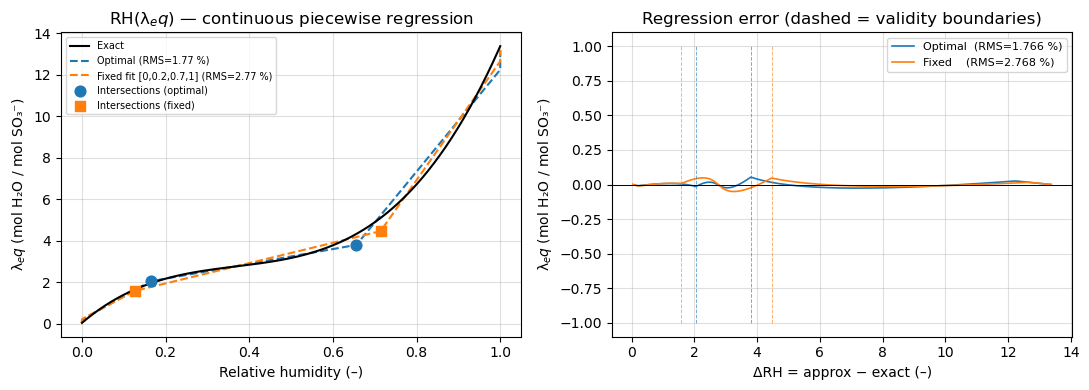

In [3]:
ionomer = cell.membrane.ionomer   # PFSAIonomer — fitted at __post_init__
T_REF = ionomer.pwl_temperature

rh_ref   = np.linspace(0.0, 1.0, 500)
lmbd_ref = ionomer.vapor_equilibrium_water_content(rh_ref, T_REF)

# ── Print segment expressions ──────────────────────────────────────────────────
n_seg = len(ionomer.pwl_slopes)
print(f"Piecewise linear regression  RH(λ$_eq$)  (T = {T_REF:.0f} K, {n_seg} segments)\n")
print(f"Fitting intervals (RH) : {np.round(ionomer.fit_rh_breaks, 4).tolist()}")
print(f"Validity intervals (λ) : {np.round(ionomer.lmbd_pwl_breaks, 4).tolist()}")
print(f"  (boundaries = line intersections → continuity guaranteed)\n")
print(f"{'k':<4} {'Validity λ interval':<24} {'a_k (slope)':>14} {'b_k (intercept)':>16}")
print("─" * 62)
for k, (a, b, lo, hi) in enumerate(zip(
    ionomer.pwl_slopes, ionomer.pwl_intercepts,
    ionomer.lmbd_pwl_breaks[:-1], ionomer.lmbd_pwl_breaks[1:],
)):
    sign = '+' if b >= 0 else '−'
    print(f"{k:<4} λ ∈ [{lo:.4f}, {hi:.4f}]     {a:>14.6f}   {b:>16.6f}")
    print(f"       RH = {a:.6f} · λ {sign} {abs(b):.6f}")

# ── Compare with fixed fitting intervals [0, 0.2, 0.7, 1] ────────────────────
fixed_fit_breaks = np.array([0.0, 0.2, 0.7, 1.0])
ionomer.fit_rh_piecewise_linear(rh_breaks=fixed_fit_breaks, temperature=T_REF)
rh_fixed = ionomer.linear_rh_from_water_content(lmbd_ref)
lmbd_valid_fixed = ionomer.lmbd_pwl_breaks.copy()
rh_valid_fixed   = ionomer.rh_pwl_breaks.copy()

# Restore optimal fit
ionomer.fit_rh_piecewise_linear(temperature=T_REF)
rh_opt       = ionomer.linear_rh_from_water_content(lmbd_ref)
lmbd_valid_opt = ionomer.lmbd_pwl_breaks.copy()
rh_valid_opt   = ionomer.rh_pwl_breaks.copy()

rms_opt   = np.sqrt(np.mean((rh_opt   - rh_ref) ** 2))
rms_fixed = np.sqrt(np.mean((rh_fixed - rh_ref) ** 2))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(rh_ref, lmbd_ref,   'k',    lw=1.5, label='Exact', zorder=3)
ax.plot(rh_opt[:-2], lmbd_ref[:-2],    'C0--', lw=1.5, label=f'Optimal (RMS={rms_opt*100:.2f} %)')
ax.plot(rh_fixed[:-2], lmbd_ref[:-2],  'C1--',  lw=1.5, label=f'Fixed fit [0,0.2,0.7,1] (RMS={rms_fixed*100:.2f} %)')
# Mark validity-interval boundaries (intersections)
ax.scatter(rh_valid_opt[1:-1], lmbd_valid_opt[1:-1],      color='C0', zorder=5, s=60, label='Intersections (optimal)')
ax.scatter(rh_valid_fixed[1:-1], lmbd_valid_fixed[1:-1],  color='C1', zorder=5, s=60, marker='s', label='Intersections (fixed)')

ax.set_ylabel('λ$_eq$ (mol H₂O / mol SO₃⁻)')
ax.set_xlabel('Relative humidity (–)')
ax.set_title('RH(λ$_eq$) — continuous piecewise regression')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(lmbd_ref, rh_opt   - rh_ref, 'C0', lw=1.2, label=f'Optimal  (RMS={rms_opt*100:.3f} %)')
ax.plot(lmbd_ref, rh_fixed - rh_ref, 'C1', lw=1.2, label=f'Fixed    (RMS={rms_fixed*100:.3f} %)')
ax.axhline(0, color='k', lw=0.7)
ax.vlines(lmbd_valid_opt[1:-1],   -1, 1, colors='C0', lw=0.7, ls='--', alpha=0.6)
ax.vlines(lmbd_valid_fixed[1:-1], -1, 1, colors='C1', lw=0.7, ls='--', alpha=0.6)
ax.set_ylabel('λ$_eq$ (mol H₂O / mol SO₃⁻)')
ax.set_xlabel('ΔRH = approx − exact (–)')
ax.set_title('Regression error (dashed = validity boundaries)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

fig.tight_layout()
plt.show()

## 2 — QSS comparison: paper model vs standard PWL water balance

Run the vectorised quasi-steady model with the `MembraneWaterBalanceModel` from
Affonso Nobrega et al. (2026) (first-order linear expansion of the sorption
isotherm) and with the standard `MembraneWaterBalanceModelPiecewise` across all
six test files.

The goal is to verify that:
1. The PWL model gives the same cell voltage / water content / HFR as the paper
   model to within the isotherm approximation error (~1.8 % RMS).
2. The self-consistency iteration always converges (segment selection stabilises
   after at most `n_segments` inner loops).

In [4]:
from scipy.signal import butter, filtfilt

from marapendi.cell.explicit_steady_state import ExplicitSteadyStateModel
from marapendi.water_balance.water_balance import WaterBalanceModel
from marapendi.water_balance.membrane import MembraneWaterBalanceModel
from marapendi.water_balance.membrane_pwl import MembraneWaterBalanceModelPiecewise

# ── Models ────────────────────────────────────────────────────────────────────
ss_paper = ExplicitSteadyStateModel(
    water_balance_model=WaterBalanceModel(
        membrane_water_balance_model=MembraneWaterBalanceModel()
    )
)
ss_pwl = ExplicitSteadyStateModel(
    water_balance_model=WaterBalanceModel(
        membrane_water_balance_model=MembraneWaterBalanceModelPiecewise()
    )
)

# ── Files & windows (same as notebook 06) ─────────────────────────────────────
FILES = [
    ("Cond. A", "data/experimental_data_MEA62_condition_A.csv", 1.63, 2.95),
    ("Cond. B", "data/experimental_data_MEA62_condition_B.csv", 1.61, 2.85),
    ("Cond. C", "data/experimental_data_MEA62_condition_C.csv", 1.62, 2.89),
    ("Cond. D", "data/experimental_data_MEA62_condition_D.csv", 2.71, 3.95),
    ("Cond. E", "data/experimental_data_MEA62_condition_E.csv", 1.50, 2.75),
    ("Cond. F", "data/experimental_data_MEA62_condition_F.csv", 1.62, 2.90),
]

CELL_AREA = 25e-4   # m²
I_MIN     = 0.5     # A
LPF_FC    = 0.1     # Hz

def load_csv(path):
    df = pd.read_csv(path, sep=";", skiprows=6, encoding="latin1")
    df = df.rename(columns=lambda c: c.strip())
    old = list(df.columns)
    df = df.reset_index()
    df.columns = ["Time(s)"] + old[1:] + ["_extra"]
    df = df.drop(columns=["_extra"])
    df["Time(h)"] = (df["Time(s)"] - df["Time(s)"].iloc[0]) / 3600.0
    return df

# ── Run ───────────────────────────────────────────────────────────────────────
RESULTS = {}

for label, path, T_START_H, T_END_H in FILES:
    print(f"\n{'─'*50}  {label}")
    df = load_csv(path)
    active = (
        (df["I_Pile(A)"] > I_MIN)
        & (df["Time(h)"] >= T_START_H)
        & (df["Time(h)"] <= T_END_H)
    ).to_numpy()
    df_a    = df[active].copy().reset_index(drop=True)
    t_rel_s = (df_a["Time(h)"] * 3600).to_numpy()
    t_rel_s -= t_rel_s[0]

    dt_s = float(np.median(np.diff(t_rel_s)))
    b_f, a_f = butter(4, LPF_FC / (1.0 / dt_s / 2), btype="low")
    lpf = lambda x: filtfilt(b_f, a_f, x)

    _I    = np.maximum(lpf(df_a["I_Pile(A)"].to_numpy()), I_MIN)
    _T_ca = lpf((df_a["T_Air_in(°C)"]   + 273.15).to_numpy())
    _p_ca = lpf((df_a["P_Air_Out(bara)"] * 1e5).to_numpy())
    _xi_ca = np.maximum(lpf(df_a["Stoeckio_air_calc"].to_numpy()), 1.01)
    _T_an  = lpf((df_a["T_H2_In(°C)"]   + 273.15).to_numpy())
    _p_an  = lpf((df_a["P_h2_out(bara)"] * 1e5).to_numpy())
    _xi_an = np.maximum(lpf(df_a["Stoeckio_h2_calc"].to_numpy()), 1.01)
    _T_c   = lpf((df_a["T_pile(°C)"]    + 273.15).to_numpy())
    _rh_ca = np.clip(lpf((df_a["RH_Air_calc(%)"] / 100.).to_numpy()), 0., 1.)
    _rh_an = np.clip(lpf((df_a["RH_h2_calc(%)"] / 100.).to_numpy()), 0., 1.)

    cond_v = mrpd.CellConditions(
        current_density=_I / CELL_AREA,
        cell_temperature=_T_c,
        ca=mrpd.SideConditions(
            inlet_temperature=_T_ca, outlet_pressure=_p_ca,
            dry_o2_mole_fraction=0.21,
            stoichiometry=_xi_ca, inlet_relative_humidity=_rh_ca,
        ),
        an=mrpd.SideConditions(
            inlet_temperature=_T_an, outlet_pressure=_p_an,
            dry_h2_mole_fraction=1.0,
            stoichiometry=_xi_an, inlet_relative_humidity=_rh_an,
        ),
    )

    # ── Paper model (linear expansion, Affonso Nobrega et al. 2026) ───────────
    t0 = time.perf_counter()
    st_e = ss_paper.set_initial_conditions(cell, cond_v)
    st_e = ss_paper.solve(cell, cond_v, st_e)
    t_paper = time.perf_counter() - t0

    hfr_e = ss_paper.voltage_model.high_frequency_resistance(cell, st_e)

    # ── Standard PWL model ────────────────────────────────────────────────────
    t0 = time.perf_counter()
    st_p = ss_pwl.set_initial_conditions(cell, cond_v)
    st_p = ss_pwl.solve(cell, cond_v, st_p)
    t_pwl = time.perf_counter() - t0

    hfr_p = ss_pwl.voltage_model.high_frequency_resistance(cell, st_p)

    cond_label = (
        f"T={np.median(_T_c)-273.15:.0f} °C  "
        f"p={np.median(_p_ca)*1e-5:.1f} bar  "
        f"RH={np.median(_rh_ca)*100:.0f} %"
    )
    print(f"  Paper {t_paper*1e3:.0f} ms   PWL {t_pwl*1e3:.0f} ms   "
          f"ΔV_max={1e3*np.max(np.abs(st_p.cell_voltage - st_e.cell_voltage)):.2f} mV")

    RESULTS[label] = dict(
        t_h=t_rel_s / 3600.,
        meas_V=df_a["U_Pile(V)"].to_numpy(),
        meas_I=_I / CELL_AREA * 1e-4,
        cond_label=cond_label,
        t_paper=t_paper, t_pwl=t_pwl,
        # paper model
        V_e  = np.atleast_1d(st_e.cell_voltage),
        lmbd_memb_e = np.atleast_1d(st_e.membrane.water_content),
        lmbd_ca_e   = np.atleast_1d(st_e.ca.cl.ionomer_water_content),
        lmbd_an_e   = np.atleast_1d(st_e.an.cl.ionomer_water_content),
        hfr_e       = np.atleast_1d(hfr_e),
        liq_ca_e    = np.atleast_1d(st_e.ca.cl.liquid_saturation),
        # pwl model
        V_p  = np.atleast_1d(st_p.cell_voltage),
        lmbd_memb_p = np.atleast_1d(st_p.membrane.water_content),
        lmbd_ca_p   = np.atleast_1d(st_p.ca.cl.ionomer_water_content),
        lmbd_an_p   = np.atleast_1d(st_p.an.cl.ionomer_water_content),
        hfr_p       = np.atleast_1d(hfr_p),
        liq_ca_p    = np.atleast_1d(st_p.ca.cl.liquid_saturation),
        # segment used (per time point)
        seg_ca = np.atleast_1d(st_p.ca.pwl_interval),
        seg_an = np.atleast_1d(st_p.an.pwl_interval),
    )

print("\nDone.")


──────────────────────────────────────────────────  Cond. A
  Paper 5 ms   PWL 8 ms   ΔV_max=2.98 mV

──────────────────────────────────────────────────  Cond. B
  Paper 5 ms   PWL 6 ms   ΔV_max=1.48 mV

──────────────────────────────────────────────────  Cond. C
  Paper 5 ms   PWL 7 ms   ΔV_max=4.75 mV

──────────────────────────────────────────────────  Cond. D
  Paper 5 ms   PWL 9 ms   ΔV_max=2.20 mV

──────────────────────────────────────────────────  Cond. E
  Paper 5 ms   PWL 6 ms   ΔV_max=9.71 mV

──────────────────────────────────────────────────  Cond. F
  Paper 4 ms   PWL 6 ms   ΔV_max=8.37 mV

Done.


### 2.1 — Cell voltage

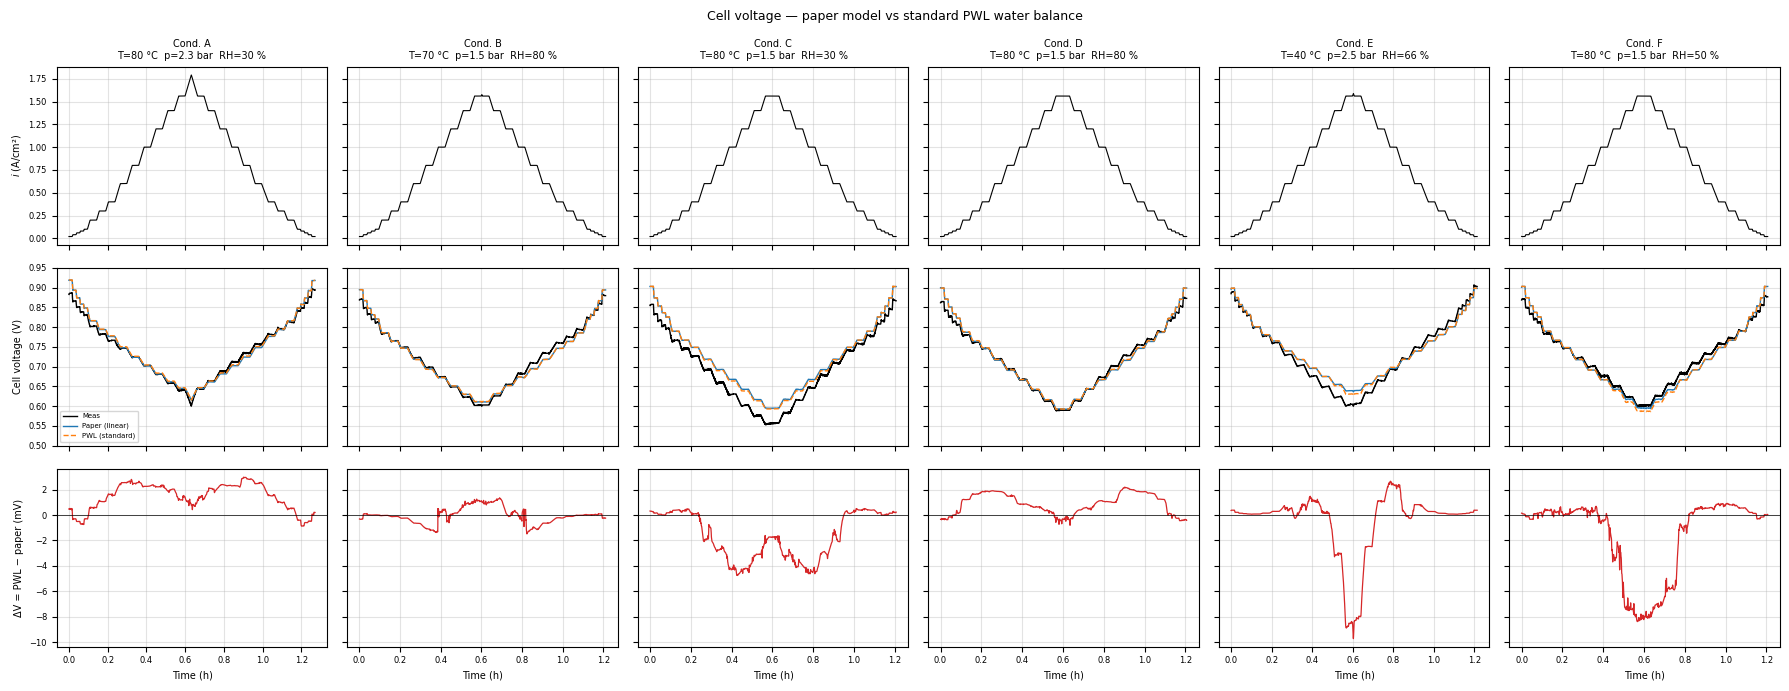

In [5]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(3, n, figsize=(3.0*n, 7), sharex="col", sharey="row")

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    axes[0, j].plot(t, r["meas_I"], "k", lw=0.8)
    axes[0, j].set_title(f"{lbl}\n{r['cond_label']}", fontsize=7)

    axes[1, j].plot(t, r["meas_V"],  "k",    lw=1.0, label="Meas")
    axes[1, j].plot(t, r["V_e"],     "C0",   lw=1.0, label="Paper (linear)")
    axes[1, j].plot(t, r["V_p"],     "C1--", lw=1.0, label="PWL (standard)")
    axes[1, j].set_ylim([0.5, 0.95])

    axes[2, j].plot(t, 1e3*(r["V_p"] - r["V_e"]), "C3", lw=0.9)
    axes[2, j].axhline(0, color="k", lw=0.5)
    axes[2, j].set_xlabel("Time (h)", fontsize=7)

axes[0, 0].set_ylabel("$i$ (A/cm²)", fontsize=7)
axes[1, 0].set_ylabel("Cell voltage (V)", fontsize=7)
axes[2, 0].set_ylabel("ΔV = PWL − paper (mV)", fontsize=7)
for i in range(3):
    for j in range(n):
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)
axes[1, 0].legend(fontsize=5)

fig.suptitle("Cell voltage — paper model vs standard PWL water balance", fontsize=9)
fig.tight_layout()
plt.show()

### 2.2 — Water content

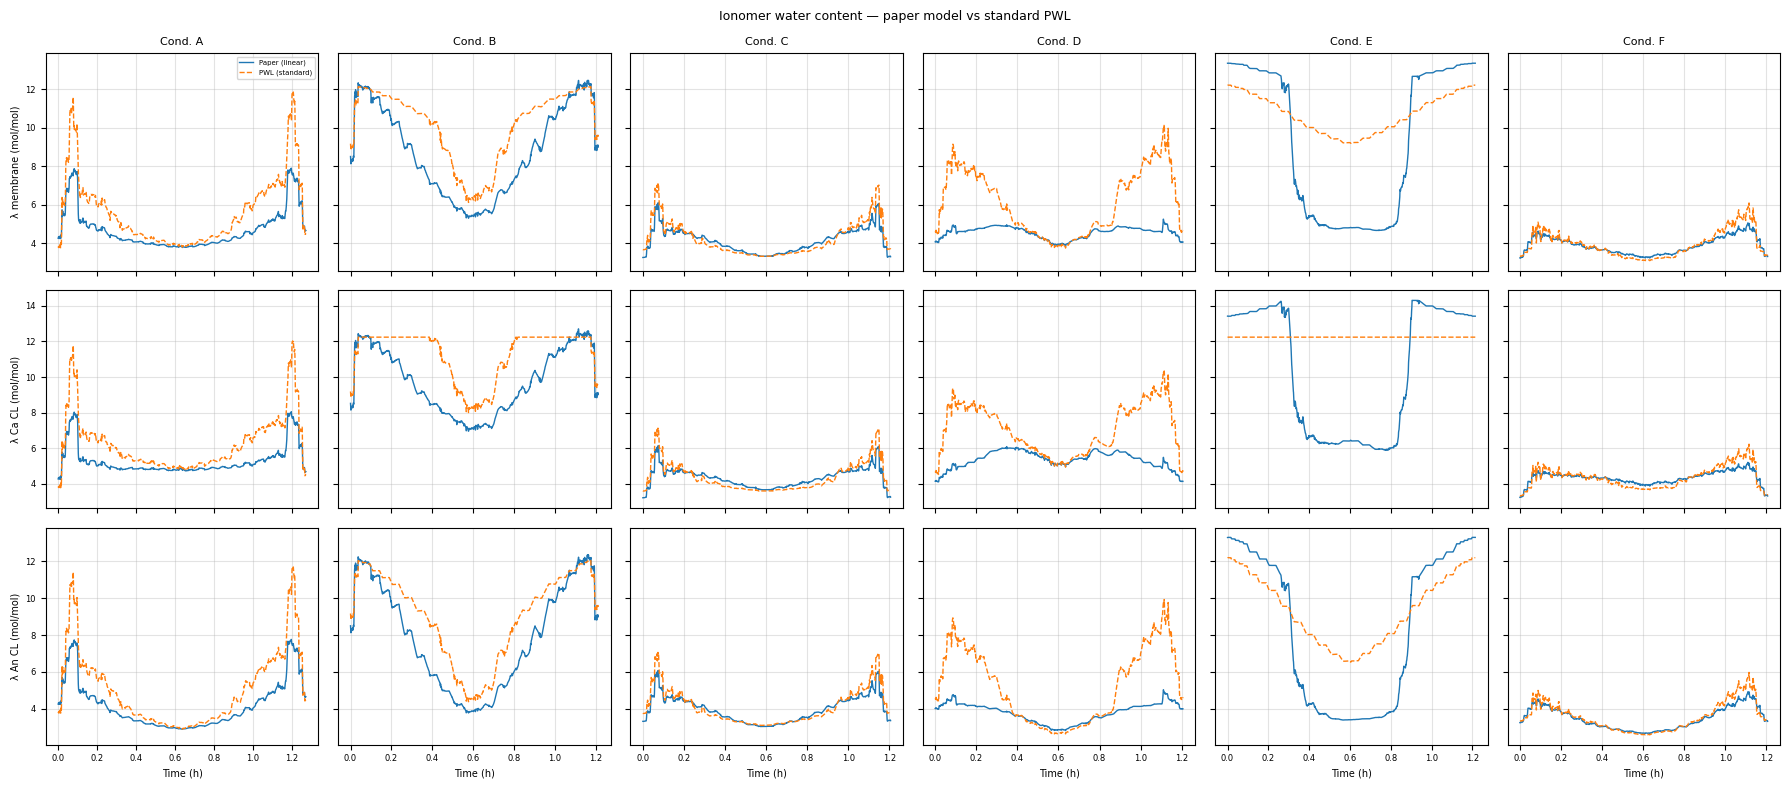

In [6]:
labels = list(RESULTS)
n = len(labels)

rows = [
    ("lmbd_memb", "λ membrane"),
    ("lmbd_ca",   "λ Ca CL"),
    ("lmbd_an",   "λ An CL"),
]

fig, axes = plt.subplots(len(rows), n, figsize=(3.0*n, 8), sharex="col", sharey="row")

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    axes[0, j].set_title(lbl, fontsize=8)
    for i, (key, ylabel) in enumerate(rows):
        axes[i, j].plot(t, r[key + "_e"], "C0",   lw=1., label="Paper (linear)")
        axes[i, j].plot(t, r[key + "_p"], "C1--", lw=1., label="PWL (standard)")
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)
    axes[-1, j].set_xlabel("Time (h)", fontsize=7)

for i, (_, ylabel) in enumerate(rows):
    axes[i, 0].set_ylabel(ylabel + " (mol/mol)", fontsize=7)
axes[0, 0].legend(fontsize=5)

fig.suptitle("Ionomer water content — paper model vs standard PWL", fontsize=9)
fig.tight_layout()
plt.show()

### 2.3 — HFR

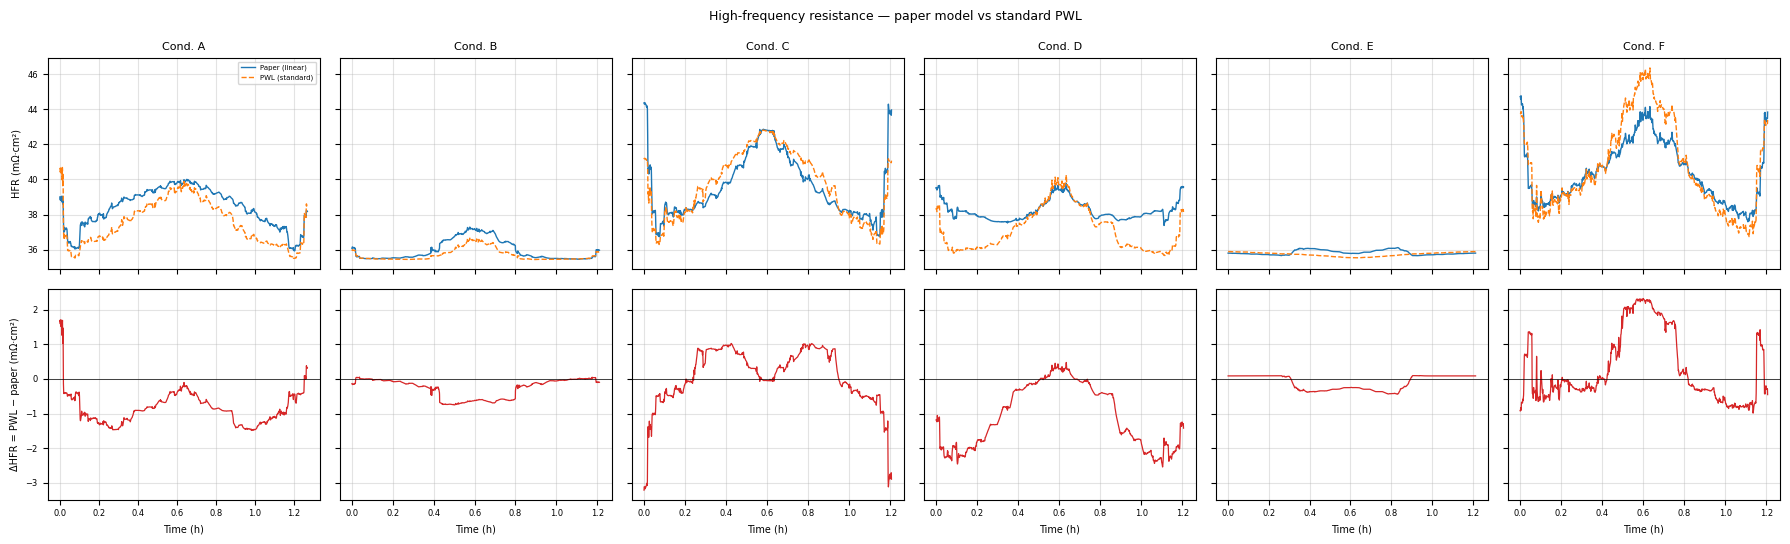

In [7]:
labels = list(RESULTS)
n = len(labels)
fig, axes = plt.subplots(2, n, figsize=(3.0*n, 5.5), sharex="col", sharey="row")

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    axes[0, j].plot(t, r["hfr_e"] * 1e7, "C0",   lw=1., label="Paper (linear)")
    axes[0, j].plot(t, r["hfr_p"] * 1e7, "C1--", lw=1., label="PWL (standard)")
    axes[0, j].set_title(lbl, fontsize=8)
    axes[1, j].plot(t, 1e7*(r["hfr_p"] - r["hfr_e"]), "C3", lw=0.9)
    axes[1, j].axhline(0, color="k", lw=0.5)
    axes[1, j].set_xlabel("Time (h)", fontsize=7)
    for i in range(2):
        axes[i, j].grid(True, alpha=0.35)
        axes[i, j].tick_params(labelsize=6)

axes[0, 0].set_ylabel("HFR (mΩ·cm²)", fontsize=7)
axes[1, 0].set_ylabel("ΔHFR = PWL − paper (mΩ·cm²)", fontsize=7)
axes[0, 0].legend(fontsize=5)

fig.suptitle("High-frequency resistance — paper model vs standard PWL", fontsize=9)
fig.tight_layout()
plt.show()

### 2.4 — Active segment per operating point

Which piecewise segment was selected after convergence for cathode and anode CLs.
A single segment across all time points means no iteration was needed; a mix
confirms the bidirectional interval search works.

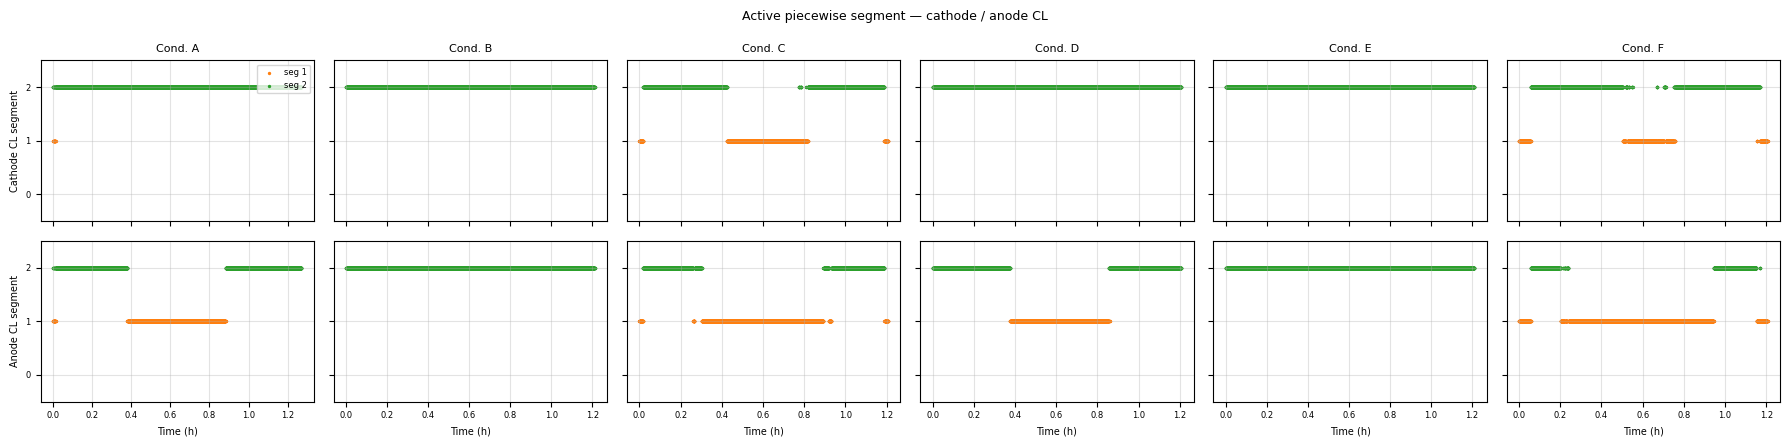


File      seg0-Ca  seg0-An  seg1-Ca  seg1-An  seg2-Ca  seg2-An
────────────────────────────────────────────
Cond. A      0.0 %     0.0 %     0.5 %    40.2 %    99.5 %    59.8 %
Cond. B      0.0 %     0.0 %     0.0 %     0.0 %   100.0 %   100.0 %
Cond. C      0.0 %     0.0 %    35.2 %    53.2 %    64.8 %    46.8 %
Cond. D      0.0 %     0.0 %     0.0 %    39.8 %   100.0 %    60.2 %
Cond. E      0.0 %     0.0 %     0.0 %     0.0 %   100.0 %   100.0 %
Cond. F      0.0 %     0.0 %    27.0 %    69.6 %    73.0 %    30.4 %


In [8]:
labels = list(RESULTS)
n = len(labels)
n_seg = len(cell.membrane.ionomer.pwl_slopes)
cmap = plt.get_cmap("tab10")
seg_colors = [cmap(k) for k in range(n_seg)]

fig, axes = plt.subplots(2, n, figsize=(3.0*n, 4.5), sharex="col", sharey="row")

for j, lbl in enumerate(labels):
    r = RESULTS[lbl]
    t = r["t_h"]
    for side, row, title in [("seg_ca", 0, "Cathode CL"), ("seg_an", 1, "Anode CL")]:
        ax = axes[row, j]
        seg = r[side]
        for k in range(n_seg):
            mask = seg == k
            if np.any(mask):
                ax.scatter(t[mask], np.full(mask.sum(), k), s=2, color=seg_colors[k],
                           label=f"seg {k}" if j == 0 else None)
        ax.set_yticks(range(n_seg))
        ax.set_ylim(-0.5, n_seg - 0.5)
        ax.grid(True, alpha=0.35)
        ax.tick_params(labelsize=6)
        if row == 0:
            ax.set_title(lbl, fontsize=8)
    axes[-1, j].set_xlabel("Time (h)", fontsize=7)

axes[0, 0].set_ylabel("Cathode CL segment", fontsize=7)
axes[1, 0].set_ylabel("Anode CL segment", fontsize=7)
if n_seg > 1:
    axes[0, 0].legend(fontsize=6, loc="upper right")

fig.suptitle("Active piecewise segment — cathode / anode CL", fontsize=9)
fig.tight_layout()
plt.show()

# Print summary table
print(f"\n{'File':<8}", end="")
for k in range(n_seg):
    print(f"  seg{k}-Ca  seg{k}-An", end="")
print()
print("─" * (8 + 12 * n_seg))
for lbl in labels:
    r = RESULTS[lbl]
    print(f"{lbl:<8}", end="")
    for k in range(n_seg):
        pct_ca = 100 * np.mean(r["seg_ca"] == k)
        pct_an = 100 * np.mean(r["seg_an"] == k)
        print(f"  {pct_ca:6.1f} %  {pct_an:6.1f} %", end="")
    print()